# 04: Heterogeneous Treatment Effects

The goal is to estimate where top-3 ranking exposure appears to matter more or less.

The previous notebooks estimated an average effect of `is_top_3` on `clicked`. That global estimate is useful, but product teams usually need a more targeted answer:

> For which users, items, and contexts does higher ranking position create the most incremental engagement?

This notebook uses doubly robust/AIPW scores to estimate segment-level effects across content categories, user-history buckets, candidate-set-size buckets, item-exposure buckets, and time-of-day buckets.

<!-- dataset-experiment-context -->
## Dataset and Design Context

This project uses the Microsoft News Dataset (MIND) impression logs. The working table is an impression-item panel: each row is one news item displayed inside a user impression slate.

This is a real observational ranking log, not a randomized ranking experiment. The treatment is top-3 exposure, the outcome is click-through, and the main causal risk is that the production ranker likely used relevance, freshness, and intent signals that are not fully observed in the public data.

The project should therefore be read as an offline causal measurement and experiment-prioritization workflow. Naive rank-position click differences are descriptive. Adjusted estimates, overlap checks, heterogeneous effects, and policy simulations are used to decide what would be credible enough to test online.

**Role of this notebook.** This notebook studies whether adjusted effects vary across content, slate, time, and exposure segments. The goal is to produce experiment candidates with clear evidentiary boundaries.

<!-- mathematical-setup -->

## Mathematical Setup

The average effect can hide important differences across content and user-history segments. For a segment \(S_i=s\), the segment-level causal effect is

$$
\tau(s)=\mathbb{E}\left[Y_i(1)-Y_i(0)\mid S_i=s\right].
$$

The notebook estimates \(\tau(s)\) by averaging doubly robust scores within each segment:

$$
\widehat{\tau}(s)=\frac{1}{n_s}\sum_{i:S_i=s}\widehat\phi_i,
$$

where \(\widehat\phi_i\) is the AIPW pseudo-outcome for impression \(i\). A segment estimate is only useful when the segment has enough treated and control observations. That is why the code applies minimum-size gates before interpreting heterogeneity patterns.


## Why Heterogeneous Effects Matter

A single average treatment effect can hide important product differences. For example, top-3 placement might be very valuable for fresh entertainment content, but less valuable for items that users would click regardless of position. It might also matter more when users face long recommendation lists because lower positions become harder to notice.

For a recommendation data science analysis project, this notebook is important because it turns the causal estimate into a product decision framework:

- Which segments are most position-sensitive?
- Which segments have little incremental benefit from top placement?
- Where might ranking changes produce the biggest engagement return?
- Where do we need more data or better overlap before making claims?

#### Setup

This cell imports the libraries used for heterogeneous effect estimation. Most of the workflow is standard pandas/numpy analysis plus scikit-learn nuisance models. We reuse the doubly robust logic from notebook 3 so notebook 4 can run independently.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

This cell prepares the notebook environment for heterogeneous treatment effects across product segments. There is no substantive model result yet; the important outcome is that the imports and display settings are ready so the next cells can focus on the data and causal question.


#### Load The Processed Impression Table

This cell loads the processed MIND-small sample created earlier. Each row is one displayed item inside a recommendation impression. That means each row has a rank position, a click outcome, item metadata, user-history context, and impression context.

In [2]:
DATA_RELATIVE_PATH = Path("data/processed/mind_small_impressions_train_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / DATA_RELATIVE_PATH).exists()
)

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH
df = pd.read_parquet(DATA_PATH)

df.shape

(737762, 20)

The loaded table preview and shape confirm that the notebook is using the expected processed dataset. This check anchors the rest of the analysis, because all treatment, outcome, and covariate definitions depend on these columns being present and correctly typed.


## Causal Setup

We keep the same causal setup as notebooks 2 and 3:

- **Treatment**: `is_top_3 = 1`, item appears in positions 1, 2, or 3.
- **Control**: `is_top_3 = 0`, item appears below position 3.
- **Outcome**: `clicked`, whether the displayed item was clicked.
- **Covariates**: observed item, user-history, and context features.

The new question moves from the global average effect to segment-specific effects:

`E[Y(1) - Y(0) | segment]`

For example, this could mean the top-3 effect within sports articles, within low-history users, or within long candidate sets.

#### Modeling Sample

This notebook recomputes cross-fitted AIPW scores so it can run independently from notebook 3. To keep the notebook interactive, we use a random modeling sample. The sample is large enough for segment analysis, but small enough that cross-fitting remains quick.

#### Create Treatment, Outcome, And Basic Features

This cell samples rows and creates clean analysis columns. `treatment` and `outcome` are explicit versions of `is_top_3` and `clicked`. `log_item_exposures` is a log-transformed exposure count used as a popularity proxy. The readable `treatment_label` is used in tables and plots.

In [3]:
MODEL_SAMPLE_SIZE = 150_000
RANDOM_STATE = 42

model_df = (
    df.sample(n=min(len(df), MODEL_SAMPLE_SIZE), random_state=RANDOM_STATE)
    .reset_index(drop=True)
    .copy()
)

model_df["treatment"] = model_df["is_top_3"].astype(int)
model_df["outcome"] = model_df["clicked"].astype(int)
model_df["log_item_exposures"] = np.log1p(model_df["item_exposures"])
model_df["treatment_label"] = np.where(model_df["treatment"] == 1, "top_3", "rank_4_plus")

pd.Series(
    {
        "rows": len(model_df),
        "treatment_rate_top_3": model_df["treatment"].mean(),
        "click_rate": model_df["outcome"].mean(),
        "unique_users": model_df["user_id"].nunique(),
        "unique_items": model_df["news_id"].nunique(),
    }
)

rows                   150000.0000
treatment_rate_top_3        0.0801
click_rate                  0.0396
unique_users            14029.0000
unique_items             6862.0000
dtype: float64

The size summary tells us the scale of the analysis population and whether the sample is large enough for ranking-position comparisons. This gives context for the more detailed distribution and treatment checks that follow.


#### Nuisance Model Features

AIPW needs a propensity model and an outcome model. We use observed user, item, and context covariates. As before, we avoid `item_clicks` and `item_ctr` as model inputs because they are computed from click outcomes in this same sample. They are useful descriptive columns, but not ideal nuisance-model inputs for a causal estimate.

#### Define Feature Lists

This cell defines the features used by the propensity and outcome models. The propensity model predicts treatment from covariates. The outcome model predicts clicks from treatment plus the same covariates. Numeric and categorical features are listed separately because they get different preprocessing.

In [4]:
numeric_features = [
    "history_len",
    "candidate_set_size",
    "title_length",
    "abstract_length",
    "hour",
    "day_of_week",
    "log_item_exposures",
]
categorical_features = ["category", "subcategory"]

propensity_features = numeric_features + categorical_features
outcome_numeric_features = numeric_features + ["treatment"]
outcome_features = outcome_numeric_features + categorical_features

X = model_df[propensity_features]
t = model_df["treatment"]

propensity_features, outcome_features

(['history_len',
  'candidate_set_size',
  'title_length',
  'abstract_length',
  'hour',
  'day_of_week',
  'log_item_exposures',
  'category',
  'subcategory'],
 ['history_len',
  'candidate_set_size',
  'title_length',
  'abstract_length',
  'hour',
  'day_of_week',
  'log_item_exposures',
  'treatment',
  'category',
  'subcategory'])

The feature lists define what information is allowed into the adjustment models. These are pre-treatment or contextual variables intended to reduce confounding without using the outcome itself as an input.


#### Reusable Model Pipelines

We use logistic regression for both nuisance models in this notebook. This keeps the model transparent and quick to fit. The goal is not to maximize predictive performance yet; the goal is to produce stable, explainable segment-level doubly robust estimates.

#### Build Preprocessing And Logistic Regression Pipelines

This cell defines helper functions for model creation. Numeric columns are imputed and scaled. Categorical columns are imputed and one-hot encoded, with rare levels grouped. The helper functions return fresh sklearn pipelines so cross-fitting can train separate models per fold.

In [5]:
# Build preprocessing and logistic regression pipelines.
def make_preprocessor(numeric_cols, categorical_cols):
    """
    Build the shared preprocessing transformer for causal nuisance models.
    
    Idea
    ----
    Numeric columns are imputed and scaled when appropriate, while categorical columns are imputed and one-hot encoded so downstream propensity and outcome models receive a consistent design matrix.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.compose.ColumnTransformer
        Configured preprocessing transformer for the specified numeric and categorical columns.
    """
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=50,
                    sparse_output=True,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )


def make_logistic_pipeline(numeric_cols, categorical_cols):
    """
    Build a logistic-regression propensity pipeline.
    
    Idea
    ----
    The pipeline combines project-specific preprocessing with a logistic model so top-rank exposure or treatment assignment can be estimated from observed covariates.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline that preprocesses covariates and fits a logistic treatment model.
    """
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_cols, categorical_cols)),
            (
                "model",
                LogisticRegression(
                    max_iter=500,
                    solver="lbfgs",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


base_propensity_model = make_logistic_pipeline(numeric_features, categorical_features)
base_outcome_model = make_logistic_pipeline(outcome_numeric_features, categorical_features)

This cell creates reusable modeling machinery for later estimates. The value is consistency. The same preprocessing and helper functions can be applied across folds, estimators, and sensitivity checks.


#### Cross-Fitted AIPW Scores

To estimate segment-level effects, we first need one AIPW score per row. The mean of AIPW scores within a segment estimates the treatment effect for that segment.

We use cross-fitting so each row's nuisance predictions are generated by models that did not train on that row. This reduces overfitting bias and makes the per-row scores more defensible.

#### Train Nuisance Models And Predict Held-Out Rows

This cell runs 3-fold cross-fitting. For each fold, it fits a propensity model and an outcome model on the training folds, then predicts on the held-out fold. For the outcome model, each held-out row is scored twice: once as if `treatment = 1` and once as if `treatment = 0`. These are the counterfactual predictions `mu1_hat` and `mu0_hat`.

In [6]:
# Train nuisance models and predict held-out rows.
N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

e_hat = np.zeros(len(model_df))
mu1_hat = np.zeros(len(model_df))
mu0_hat = np.zeros(len(model_df))

propensity_metrics = []
outcome_metrics = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, t), start=1):
    train_df = model_df.iloc[train_idx]
    valid_df = model_df.iloc[valid_idx]

    propensity_model = clone(base_propensity_model)
    propensity_model.fit(train_df[propensity_features], train_df["treatment"])
    e_valid = propensity_model.predict_proba(valid_df[propensity_features])[:, 1]
    e_hat[valid_idx] = e_valid

    outcome_model = clone(base_outcome_model)
    outcome_model.fit(train_df[outcome_features], train_df["outcome"])

    valid_actual = valid_df[outcome_features]
    y_valid_hat = outcome_model.predict_proba(valid_actual)[:, 1]

    valid_treated = valid_df[propensity_features].copy()
    valid_treated["treatment"] = 1
    valid_treated = valid_treated[outcome_features]

    valid_control = valid_df[propensity_features].copy()
    valid_control["treatment"] = 0
    valid_control = valid_control[outcome_features]

    mu1_hat[valid_idx] = outcome_model.predict_proba(valid_treated)[:, 1]
    mu0_hat[valid_idx] = outcome_model.predict_proba(valid_control)[:, 1]

    propensity_metrics.append(
        {
            "fold": fold,
            "roc_auc": roc_auc_score(valid_df["treatment"], e_valid),
            "average_precision": average_precision_score(valid_df["treatment"], e_valid),
            "brier_score": brier_score_loss(valid_df["treatment"], e_valid),
        }
    )
    outcome_metrics.append(
        {
            "fold": fold,
            "roc_auc": roc_auc_score(valid_df["outcome"], y_valid_hat),
            "average_precision": average_precision_score(valid_df["outcome"], y_valid_hat),
            "brier_score": brier_score_loss(valid_df["outcome"], y_valid_hat),
        }
    )

model_df["e_hat"] = e_hat
model_df["mu1_hat"] = mu1_hat
model_df["mu0_hat"] = mu0_hat
model_df["mu_diff_hat"] = model_df["mu1_hat"] - model_df["mu0_hat"]

pd.DataFrame(propensity_metrics)

,fold,roc_auc,average_precision,brier_score
0,1,0.7769,0.3407,0.0660
1,2,0.7622,0.3058,0.0668
2,3,0.7661,0.3205,0.0665


This output is part of the heterogeneous treatment effects across product segments workflow. Read it as a checkpoint: it either verifies an input, defines reusable analysis machinery, or produces a diagnostic that motivates the next step in the notebook.


#### Inspect Outcome Model Metrics

This cell shows the held-out predictive performance of the outcome model across folds. Clicks are sparse, so average precision is often more informative than accuracy. These metrics are diagnostics for nuisance models, not the final causal answer.

In [7]:
pd.DataFrame(outcome_metrics)

,fold,roc_auc,average_precision,brier_score
0,1,0.7119,0.1232,0.0363
1,2,0.6934,0.1111,0.0371
2,3,0.7098,0.1132,0.0368


The nuisance-model metrics show how well the supporting prediction models perform. Weak nuisance models can make IPW, DR, and policy estimates less reliable, so these diagnostics help judge the stability of the causal workflow.


#### Compute Per-Row AIPW Scores

This cell applies the AIPW formula to every row. The mean of `aipw_score` across all rows is the global doubly robust estimate. The mean within a segment is the segment-specific doubly robust estimate. Propensity scores are clipped away from 0 and 1 for numerical stability.

In [8]:
EPS = 0.01

e = model_df["e_hat"].clip(EPS, 1 - EPS).to_numpy()
mu1 = model_df["mu1_hat"].to_numpy()
mu0 = model_df["mu0_hat"].to_numpy()
t_np = model_df["treatment"].to_numpy()
y_np = model_df["outcome"].to_numpy()

model_df["aipw_score"] = (mu1 - mu0) + t_np * (y_np - mu1) / e - (1 - t_np) * (y_np - mu0) / (1 - e)

global_dr_lift = model_df["aipw_score"].mean()
global_dr_se = model_df["aipw_score"].std(ddof=1) / np.sqrt(len(model_df))

pd.Series(
    {
        "global_dr_lift": global_dr_lift,
        "standard_error": global_dr_se,
        "ci_95_lower": global_dr_lift - 1.96 * global_dr_se,
        "ci_95_upper": global_dr_lift + 1.96 * global_dr_se,
    }
)

global_dr_lift   0.0111
standard_error   0.0025
ci_95_lower      0.0062
ci_95_upper      0.0161
dtype: float64

The AIPW score combines outcome-model predictions with propensity-weighted residual corrections. This is the key doubly robust object: it can remain consistent if either the propensity model or the outcome model is correctly specified.


#### Check Nuisance Prediction Distributions

This cell summarizes propensity scores, outcome-model predictions, and AIPW scores. It helps catch instability before segmenting the estimate. Extreme AIPW score tails can make segment-level estimates noisy, especially for small segments.

In [9]:
model_df[["e_hat", "mu1_hat", "mu0_hat", "mu_diff_hat", "aipw_score"]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]
)

,e_hat,mu1_hat,mu0_hat,mu_diff_hat,aipw_score
count,150000.0000,150000.0000,150000.0000,150000.0000,150000.0000
mean,0.0801,0.0644,0.0360,0.0283,0.0111
std,0.0728,0.0442,0.0258,0.0186,0.9733
min,0.0001,0.0008,0.0004,0.0003,-8.2176
1%,0.0005,0.0044,0.0023,0.0020,-1.2288
5%,0.0033,0.0113,0.0061,0.0052,-0.8844
10%,0.0077,0.0173,0.0093,0.0080,-0.3209
50%,0.0575,0.0547,0.0300,0.0246,0.0473
90%,0.1892,0.1280,0.0727,0.0551,0.1285
95%,0.2280,0.1535,0.0884,0.0652,0.1622


The nuisance prediction summaries check the range of predicted propensities and potential outcomes. Reasonable ranges are important because AIPW scores combine these predictions with observed outcomes. This matters because the causal estimate is built from these supporting predictions, so weak nuisance behavior should make the downstream effect estimate less persuasive.


### Create Product-Relevant Segments

The segment definitions should reflect product questions. We create segments that map to common recommendation-system concerns:

- Content category and subcategory.
- User history depth.
- Candidate set size.
- Item exposure/popularity.
- Time of day.

These segments are interpretable and easy to explain in a project report.

#### Build Segment Columns

This cell adds bucketed segment columns to `model_df`. Buckets make continuous variables easier to interpret. For item exposure, we use quartiles based on ranked exposure counts so each bucket has a similar number of rows even when exposure counts are skewed.

In [10]:
model_df["history_bucket"] = pd.cut(
    model_df["history_len"],
    bins=[-1, 0, 10, 30, 100, np.inf],
    labels=["0", "1-10", "11-30", "31-100", "101+"],
)

model_df["candidate_set_bucket"] = pd.cut(
    model_df["candidate_set_size"],
    bins=[0, 10, 25, 50, 100, np.inf],
    labels=["1-10", "11-25", "26-50", "51-100", "101+"],
    include_lowest=True,
)

model_df["item_exposure_quartile"] = pd.qcut(
    model_df["item_exposures"].rank(method="first"),
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
)

model_df["time_of_day"] = pd.cut(
    model_df["hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["overnight", "morning", "afternoon", "evening", "late_evening"],
)

model_df[["history_bucket", "candidate_set_bucket", "item_exposure_quartile", "time_of_day"]].head()

,history_bucket,candidate_set_bucket,item_exposure_quartile,time_of_day
0,31-100,26-50,Q2,afternoon
1,31-100,51-100,Q2,overnight
2,31-100,51-100,Q2,afternoon
3,31-100,51-100,Q3,morning
4,31-100,51-100,Q2,morning


The segment columns translate raw covariates into product-readable groups. This prepares the analysis for heterogeneity and policy simulation, where segment-level effects are easier to act on than row-level scores.


### Segment Effect Estimator

For each segment, we compute:

- Number of rows.
- Number of treated and control rows.
- Naive lift within the segment.
- Doubly robust lift within the segment.
- Standard error and 95% confidence interval for the segment DR lift.

Small segments can produce unstable estimates, so the helper function filters out segments with too few rows or too few treated/control examples.

#### Define Segment Summary Functions

This cell defines reusable functions for segment analysis. `segment_effects` computes a table of estimates for one segment column. `plot_segment_effects` creates a horizontal confidence-interval plot for a segment table.

In [11]:
# Define segment summary functions.
def segment_effects(data, segment_col, min_rows=1_000, min_treated=50, min_control=500):
    """
    Estimate treatment effects within candidate policy segments.
    
    Idea
    ----
    The function filters segments with enough treated and control observations, then computes naive and adjusted segment effects used for targeting and experiment-prioritization.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    segment_col : object
        Column defining the segment to summarize.
    min_rows : object
        Minimum rows required to keep a segment.
    min_treated : object
        Minimum treated rows required to keep a segment.
    min_control : object
        Minimum control rows required to keep a segment.
    
    Returns
    -------
    pandas.DataFrame
        Segment-level effect table with counts, estimates, uncertainty, and candidate opportunities.
    """
    rows = []
    for segment_value, group in data.groupby(segment_col, observed=True, dropna=False):
        n_rows = len(group)
        treated_rows = int(group["treatment"].sum())
        control_rows = n_rows - treated_rows

        if n_rows < min_rows or treated_rows < min_treated or control_rows < min_control:
            continue

        treated_ctr = group.loc[group["treatment"] == 1, "outcome"].mean()
        control_ctr = group.loc[group["treatment"] == 0, "outcome"].mean()
        naive_lift = treated_ctr - control_ctr

        scores = group["aipw_score"].to_numpy()
        dr_lift = scores.mean()
        standard_error = scores.std(ddof=1) / np.sqrt(n_rows)

        rows.append(
            {
                "segment_col": segment_col,
                "segment": str(segment_value),
                "rows": n_rows,
                "treated_rows": treated_rows,
                "control_rows": control_rows,
                "treated_ctr": treated_ctr,
                "control_ctr": control_ctr,
                "naive_lift": naive_lift,
                "dr_lift": dr_lift,
                "standard_error": standard_error,
                "ci_95_lower": dr_lift - 1.96 * standard_error,
                "ci_95_upper": dr_lift + 1.96 * standard_error,
            }
        )

    return pd.DataFrame(rows).sort_values("dr_lift", ascending=False).reset_index(drop=True)


def plot_segment_effects(effect_df, title, max_segments=15):
    """
    Plot the largest segment-level treatment effects.
    
    Idea
    ----
    The figure helps compare heterogeneous effect estimates and uncertainty before deciding which segments deserve follow-up experiments.
    
    Parameters
    ----------
    effect_df : object
        Segment effect table used for ranking or allocation.
    title : object
        Plot title.
    max_segments : object
        Maximum number of segments to display.
    
    Returns
    -------
    matplotlib.axes.Axes
        Axis containing the segment-effect plot.
    """
    plot_df = effect_df.head(max_segments).sort_values("dr_lift")
    y = np.arange(len(plot_df))
    lower_error = plot_df["dr_lift"] - plot_df["ci_95_lower"]
    upper_error = plot_df["ci_95_upper"] - plot_df["dr_lift"]

    plt.figure(figsize=(10, max(4, 0.38 * len(plot_df))))
    plt.errorbar(
        x=plot_df["dr_lift"],
        y=y,
        xerr=[lower_error, upper_error],
        fmt="o",
        capsize=3,
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.yticks(y, plot_df["segment"])
    plt.title(title)
    plt.xlabel("Doubly robust lift in click probability")
    plt.ylabel("Segment")
    plt.tight_layout()

This helper defines how segment-level effects will be computed and filtered. Minimum row, treatment, and control counts keep the segment results from being driven by tiny groups.


### Effects by Category

Category-level effects answer whether broad content types are more or less position-sensitive. This is a useful product lens because ranking policies often need to balance different content families.

#### Estimate Category-Level Effects

This cell estimates doubly robust lift separately for each broad category. The table is sorted by `dr_lift`, so the top rows are the categories with the largest estimated top-3 effect among segments that pass the minimum sample-size filters.

In [12]:
category_effects = segment_effects(model_df, "category", min_rows=1_000, min_treated=50, min_control=500)
category_effects

,segment_col,segment,rows,treated_rows,control_rows,treated_ctr,control_ctr,naive_lift,dr_lift,standard_error,ci_95_lower,ci_95_upper
0,category,weather,2229,282,1947,0.1915,0.0370,0.1545,0.0501,0.0122,0.0261,0.0741
1,category,tv,6458,594,5864,0.1734,0.0425,0.1309,0.0341,0.0088,0.0168,0.0515
2,category,movies,3442,249,3193,0.0683,0.0263,0.0420,0.0309,0.0300,-0.0279,0.0897
3,category,health,7739,442,7297,0.0475,0.0306,0.0170,0.0303,0.0235,-0.0158,0.0764
4,category,music,6949,740,6209,0.1608,0.0480,0.1128,0.0232,0.0159,-0.0079,0.0542
5,category,sports,15075,1323,13752,0.1406,0.0391,0.1015,0.0192,0.0075,0.0046,0.0338
6,category,foodanddrink,9425,508,8917,0.0669,0.0267,0.0402,0.0180,0.0133,-0.0081,0.0441
7,category,news,40583,3685,36898,0.1085,0.0366,0.0719,0.0100,0.0033,0.0036,0.0165
8,category,video,2297,201,2096,0.0896,0.0406,0.0490,0.0070,0.0147,-0.0219,0.0358
9,category,entertainment,9061,674,8387,0.0579,0.0248,0.0331,0.0069,0.0108,-0.0143,0.0281


The category-level table estimates where top-rank exposure appears most or least valuable across content categories. These differences are useful for product strategy, but they should be read with uncertainty and sample-size filters in mind.


#### Plot Category-Level Effects

This cell visualizes the category-level doubly robust estimates with 95% confidence intervals. Segments whose intervals are entirely above zero have evidence of positive top-3 lift under the model assumptions. Wide intervals suggest the segment estimate is noisy.

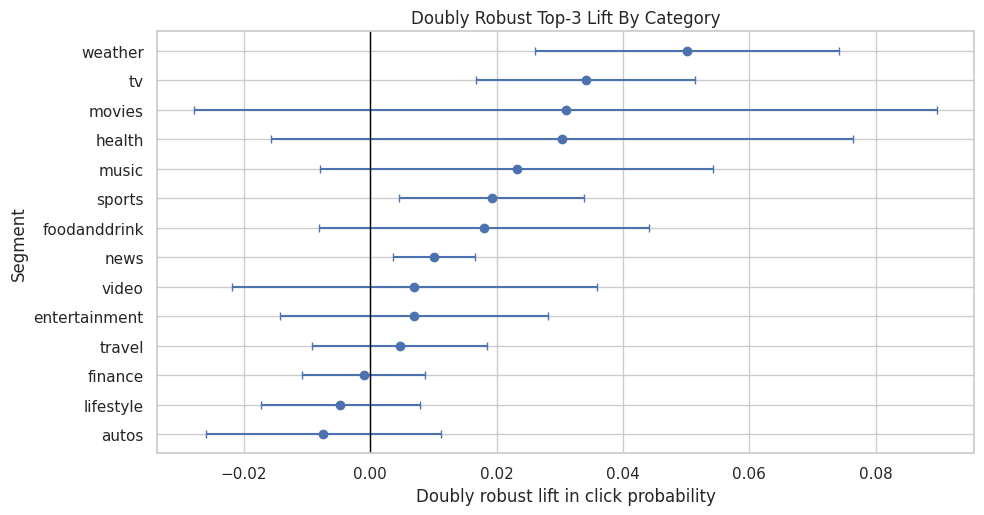

In [13]:
plot_segment_effects(category_effects, "Doubly Robust Top-3 Lift By Category")

The category-level table estimates where top-rank exposure appears most or least valuable across content categories. These differences are useful for product strategy, but they should be read with uncertainty and sample-size filters in mind.


### Effects by Subcategory

Subcategories are more granular than categories. They can reveal product patterns that broad categories hide. Because subcategories can be sparse, we use stricter filtering and focus on subcategories with enough treated and control rows.

#### Estimate Subcategory-Level Effects

This cell estimates doubly robust lift for subcategories. The result can be used to identify more specific content areas where rank position appears especially important. These estimates should be interpreted carefully because granular segments have less data.

In [14]:
subcategory_effects = segment_effects(model_df, "subcategory", min_rows=1_500, min_treated=75, min_control=750)
subcategory_effects.head(20)

,segment_col,segment,rows,treated_rows,control_rows,treated_ctr,control_ctr,naive_lift,dr_lift,standard_error,ci_95_lower,ci_95_upper
0,subcategory,tvnews,2051,282,1769,0.2270,0.0543,0.1727,0.0655,0.0161,0.0339,0.0971
1,subcategory,weathertopstories,2229,282,1947,0.1915,0.0370,0.1545,0.0501,0.0122,0.0261,0.0741
2,subcategory,tv-celebrity,2665,214,2451,0.1776,0.0465,0.1311,0.0477,0.0168,0.0148,0.0805
3,subcategory,restaurantsandnews,1692,98,1594,0.0918,0.0270,0.0649,0.0460,0.0505,-0.0531,0.1450
4,subcategory,cma-awards,2034,126,1908,0.0317,0.0257,0.0061,0.0294,0.0494,-0.0674,0.1261
5,subcategory,music-celebrity,2460,342,2118,0.1959,0.0699,0.1260,0.0282,0.0151,-0.0015,0.0579
6,subcategory,traveltripideas,2225,125,2100,0.0800,0.0214,0.0586,0.0278,0.0203,-0.0120,0.0676
7,subcategory,elections-2020-us,2262,249,2013,0.1205,0.0373,0.0832,0.0271,0.0232,-0.0184,0.0726
8,subcategory,football_nfl,6235,674,5561,0.1884,0.0500,0.1384,0.0251,0.0077,0.0099,0.0402
9,subcategory,finance-companies,4255,476,3779,0.1408,0.0466,0.0942,0.0247,0.0134,-0.0014,0.0509


The category-level table estimates where top-rank exposure appears most or least valuable across content categories. These differences are useful for product strategy, but they should be read with uncertainty and sample-size filters in mind.


#### Plot Top Subcategory Effects

This plot shows the subcategories with the largest estimated doubly robust lift. It is useful for product storytelling and also reveals multiple-comparisons risk. Treat these as hypotheses for deeper analysis.

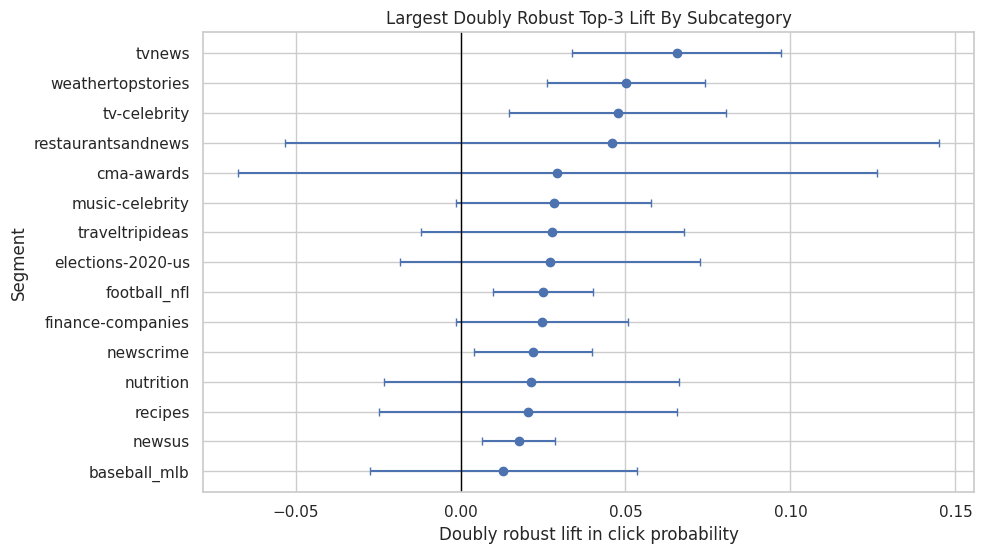

In [15]:
plot_segment_effects(subcategory_effects, "Largest Doubly Robust Top-3 Lift By Subcategory", max_segments=15)

The subcategory results drill into more granular content groups. Because finer segments have smaller sample sizes, these estimates are best used for hypothesis generation.


### Effects by User History Depth

User history depth is a proxy for how much prior behavior the system has about the user. A rank-position effect may differ between cold-start or low-history users and users with long histories.

#### Estimate Effects By History Bucket

This cell estimates doubly robust top-3 lift for each user-history bucket. If low-history users show stronger effects, that could mean position matters more when personalization has less information. If high-history users show stronger effects, that could mean ranked personalization is especially effective for known users.

In [16]:
history_effects = segment_effects(model_df, "history_bucket", min_rows=1_000, min_treated=50, min_control=500)
history_effects

,segment_col,segment,rows,treated_rows,control_rows,treated_ctr,control_ctr,naive_lift,dr_lift,standard_error,ci_95_lower,ci_95_upper
0,history_bucket,1-10,39649,3573,36076,0.1184,0.0311,0.0873,0.0168,0.0040,0.0088,0.0247
1,history_bucket,101+,10449,725,9724,0.0966,0.0467,0.0499,0.0103,0.0132,-0.0155,0.0361
2,history_bucket,11-30,49100,3896,45204,0.1001,0.0325,0.0676,0.0102,0.0039,0.0025,0.0179
3,history_bucket,31-100,47750,3606,44144,0.0885,0.0356,0.0528,0.0080,0.0051,-0.0020,0.0180
4,history_bucket,0,3052,213,2839,0.1033,0.0313,0.0719,0.0057,0.0089,-0.0117,0.0231


The history-bucket results show whether rank exposure matters differently for users with shallow versus deep prior histories. This is directly relevant to personalization because new and experienced users may respond differently.


#### Plot Effects By History Bucket

This cell plots the user-history bucket estimates. The confidence intervals help distinguish meaningful differences from noise. The chart is a product-facing way to discuss whether rank position is more important for users with sparse or rich histories.

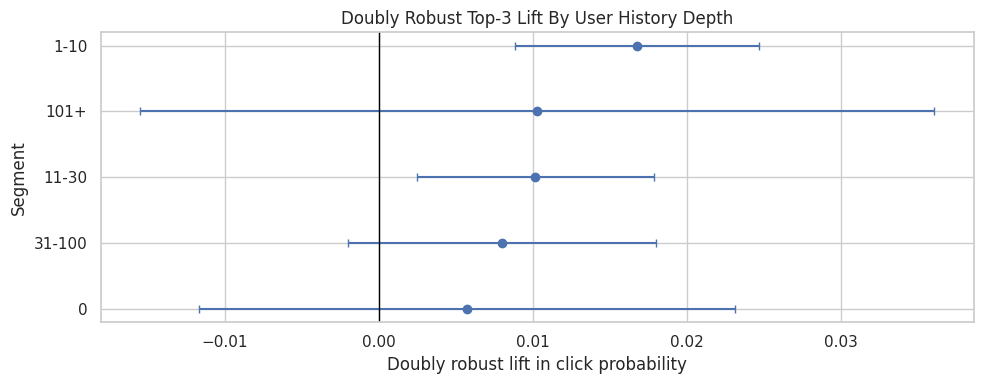

In [17]:
plot_segment_effects(history_effects, "Doubly Robust Top-3 Lift By User History Depth")

The history-bucket results show whether rank exposure matters differently for users with shallow versus deep prior histories. This is directly relevant to personalization because new and experienced users may respond differently.


### Effects by Candidate Set Size

Candidate set size describes how many items appeared in the same impression. Longer lists may create more attention decay, so top-3 placement could be more valuable when users are shown many options.

#### Estimate Effects By Candidate Set Bucket

This cell estimates doubly robust lift for each candidate-set-size bucket. The result helps answer whether position bias is stronger in longer slates than shorter slates.

In [18]:
candidate_effects = segment_effects(model_df, "candidate_set_bucket", min_rows=1_000, min_treated=50, min_control=500)
candidate_effects

,segment_col,segment,rows,treated_rows,control_rows,treated_ctr,control_ctr,naive_lift,dr_lift,standard_error,ci_95_lower,ci_95_upper
0,candidate_set_bucket,1-10,5865,3068,2797,0.2627,0.1376,0.1251,0.2275,0.0161,0.1959,0.2591
1,candidate_set_bucket,26-50,35116,3030,32086,0.0462,0.0430,0.0032,0.0142,0.0030,0.0083,0.0202
2,candidate_set_bucket,11-25,16951,2895,14056,0.0739,0.0706,0.0033,0.0067,0.0050,-0.0030,0.0164
3,candidate_set_bucket,51-100,48463,2052,46411,0.0249,0.0265,-0.0017,0.0022,0.0033,-0.0043,0.0086
4,candidate_set_bucket,101+,43605,968,42637,0.0134,0.0169,-0.0035,-0.0088,0.0068,-0.0222,0.0046


The candidate-set results check whether ranking lift changes when users face larger or smaller recommendation slates. That matters because position effects can depend on how much choice the user sees.


#### Plot Effects By Candidate Set Bucket

This cell visualizes the candidate-set bucket estimates. If larger slates have higher top-3 lift, that supports the idea that visibility matters more when there are many competing items.

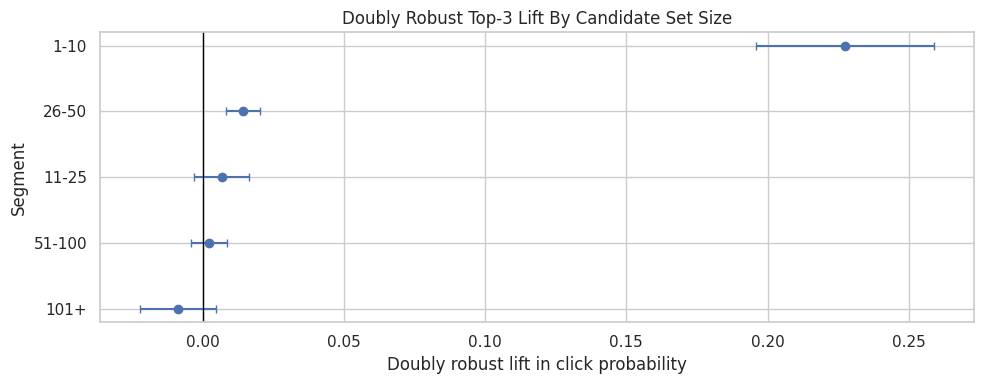

In [19]:
plot_segment_effects(candidate_effects, "Doubly Robust Top-3 Lift By Candidate Set Size")

The candidate-set results check whether ranking lift changes when users face larger or smaller recommendation slates. That matters because position effects can depend on how much choice the user sees.


### Effects by Item Exposure Level

Item exposure is a simple popularity/visibility proxy. The top-3 effect may differ between rarely exposed items and frequently exposed items. For example, highly exposed items may already have strong baseline demand, while lower-exposure items may depend more on prominent placement.

#### Estimate Effects By Exposure Quartile

This cell estimates doubly robust lift across item-exposure quartiles. Because exposure counts are skewed, quartiles are useful: each bucket has a roughly similar number of displayed rows, which keeps estimates more stable.

In [20]:
exposure_effects = segment_effects(model_df, "item_exposure_quartile", min_rows=1_000, min_treated=50, min_control=500)
exposure_effects

,segment_col,segment,rows,treated_rows,control_rows,treated_ctr,control_ctr,naive_lift,dr_lift,standard_error,ci_95_lower,ci_95_upper
0,item_exposure_quartile,Q4 highest,37500,4525,32975,0.1421,0.0469,0.0952,0.0190,0.0032,0.0128,0.0253
1,item_exposure_quartile,Q3,37500,3248,34252,0.0927,0.0343,0.0583,0.0121,0.0052,0.0018,0.0223
2,item_exposure_quartile,Q2,37500,2327,35173,0.0688,0.0275,0.0412,0.0080,0.0050,-0.0019,0.0179
3,item_exposure_quartile,Q1 lowest,37500,1913,35587,0.0627,0.0287,0.0341,0.0055,0.0062,-0.0066,0.0176


The exposure-quartile results compare items with different baseline visibility. This helps separate rank effects from item popularity dynamics that may already favor highly exposed items. The implication is that heterogeneity should guide follow-up experimentation or guardrails, not simply be read as a ranking of attractive segments.


#### Plot Effects By Exposure Quartile

This cell plots top-3 lift by exposure quartile. The result can support a product interpretation about whether prominent ranking is more useful for already-popular items or for items that otherwise receive less exposure.

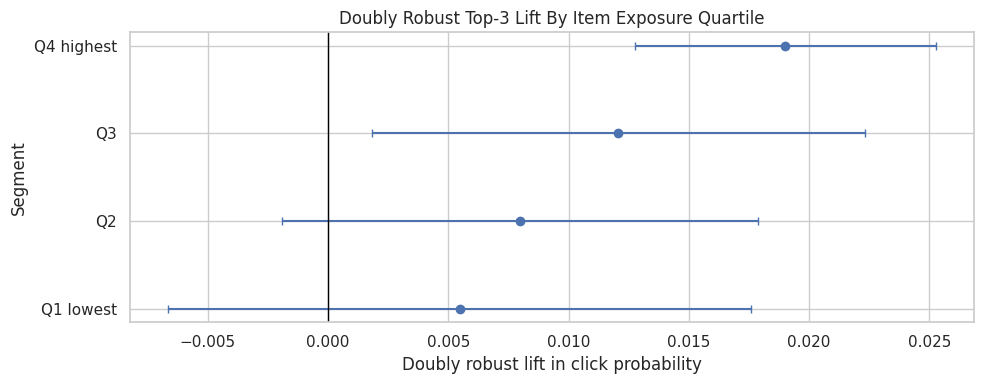

In [21]:
plot_segment_effects(exposure_effects, "Doubly Robust Top-3 Lift By Item Exposure Quartile")

The exposure-quartile results compare items with different baseline visibility. This helps separate rank effects from item popularity dynamics that may already favor highly exposed items. The implication is that heterogeneity should guide follow-up experimentation or guardrails, not simply be read as a ranking of attractive segments.


### Effects by Time of Day

User attention and browsing behavior may change throughout the day. Segmenting by time of day can reveal whether top placement matters more during certain browsing contexts.

#### Estimate Effects By Time Of Day

This cell estimates doubly robust top-3 lift for each time-of-day bucket. Time segments are broad enough to remain interpretable without being too sparse.

In [22]:
time_effects = segment_effects(model_df, "time_of_day", min_rows=1_000, min_treated=50, min_control=500)
time_effects

,segment_col,segment,rows,treated_rows,control_rows,treated_ctr,control_ctr,naive_lift,dr_lift,standard_error,ci_95_lower,ci_95_upper
0,time_of_day,afternoon,41771,3354,38417,0.0987,0.0327,0.0660,0.0145,0.0049,0.0049,0.0242
1,time_of_day,overnight,21507,1552,19955,0.1108,0.0318,0.0790,0.0130,0.0061,0.0010,0.0250
2,time_of_day,morning,65442,5396,60046,0.1042,0.0361,0.0680,0.0108,0.0039,0.0032,0.0184
3,time_of_day,late_evening,4993,452,4541,0.1173,0.0381,0.0792,0.0100,0.0116,-0.0128,0.0329
4,time_of_day,evening,16287,1259,15028,0.0842,0.0317,0.0525,0.0018,0.0075,-0.0129,0.0165


The time-of-day results check whether the ranking effect changes across usage contexts. Different browsing moments can have different intent, so this is a useful product diagnostic.


#### Plot Effects By Time Of Day

This cell visualizes time-of-day effect estimates. Differences here can become hypotheses about user attention patterns, though time-of-day effects should be interpreted cautiously because they can correlate with content mix and user mix.

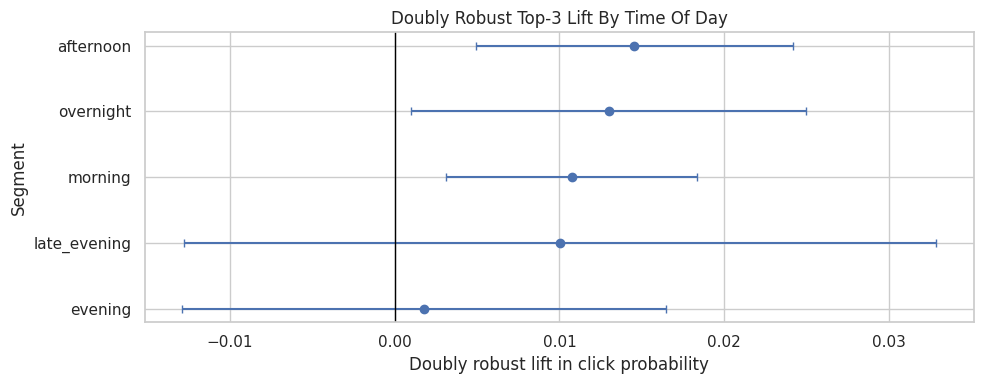

In [23]:
plot_segment_effects(time_effects, "Doubly Robust Top-3 Lift By Time Of Day")

The time-of-day results check whether the ranking effect changes across usage contexts. Different browsing moments can have different intent, so this is a useful product diagnostic.


### Product Summary Table

The previous sections looked at each segmentation dimension separately. This section combines all segment tables into one product summary so we can quickly see the strongest and weakest estimated effects across the notebook.

#### Combine Segment Results

This cell stacks all segment-effect tables and sorts them by estimated doubly robust lift. The top rows show segments where top-3 placement appears most valuable. The bottom rows show segments where estimated lift is smallest. This table is a starting point for product interpretation, not a final ranking policy.

In [24]:
all_effects = pd.concat(
    [
        category_effects,
        subcategory_effects,
        history_effects,
        candidate_effects,
        exposure_effects,
        time_effects,
    ],
    ignore_index=True,
)

summary_cols = [
    "segment_col",
    "segment",
    "rows",
    "treated_rows",
    "control_rows",
    "naive_lift",
    "dr_lift",
    "ci_95_lower",
    "ci_95_upper",
]

all_effects[summary_cols].sort_values("dr_lift", ascending=False).head(20)

,segment_col,segment,rows,treated_rows,control_rows,naive_lift,dr_lift,ci_95_lower,ci_95_upper
50,candidate_set_bucket,1-10,5865,3068,2797,0.1251,0.2275,0.1959,0.2591
14,subcategory,tvnews,2051,282,1769,0.1727,0.0655,0.0339,0.0971
15,subcategory,weathertopstories,2229,282,1947,0.1545,0.0501,0.0261,0.0741
0,category,weather,2229,282,1947,0.1545,0.0501,0.0261,0.0741
16,subcategory,tv-celebrity,2665,214,2451,0.1311,0.0477,0.0148,0.0805
17,subcategory,restaurantsandnews,1692,98,1594,0.0649,0.0460,-0.0531,0.1450
1,category,tv,6458,594,5864,0.1309,0.0341,0.0168,0.0515
2,category,movies,3442,249,3193,0.0420,0.0309,-0.0279,0.0897
3,category,health,7739,442,7297,0.0170,0.0303,-0.0158,0.0764
18,subcategory,cma-awards,2034,126,1908,0.0061,0.0294,-0.0674,0.1261


The combined segment table creates one place to compare heterogeneous effects across dimensions. This makes it easier to identify robust high-lift segments from a common view.


#### Inspect Segments With The Smallest Estimated Lift

This cell shows the lowest estimated segment effects. These segments may be less position-sensitive, too noisy, or poorly supported by the data. Product decisions need to know both where top placement helps most and where it is less incremental.

In [25]:
all_effects[summary_cols].sort_values("dr_lift", ascending=True).head(20)

,segment_col,segment,rows,treated_rows,control_rows,naive_lift,dr_lift,ci_95_lower,ci_95_upper
44,subcategory,autosenthusiasts,1693,84,1609,-0.0192,-0.0297,-0.0468,-0.0125
43,subcategory,markets,3302,213,3089,0.0104,-0.0148,-0.0287,-0.0010
42,subcategory,lifestyleroyals,3718,272,3446,0.0664,-0.0092,-0.0277,0.0093
54,candidate_set_bucket,101+,43605,968,42637,-0.0035,-0.0088,-0.0222,0.0046
41,subcategory,celebrity,4296,310,3986,0.0216,-0.0085,-0.0209,0.0039
13,category,autos,7047,391,6656,0.0070,-0.0074,-0.0261,0.0113
40,subcategory,football_ncaa,1884,126,1758,0.0424,-0.0064,-0.0373,0.0245
39,subcategory,foodnews,3205,163,3042,0.0286,-0.0055,-0.0254,0.0145
12,category,lifestyle,16973,1264,15709,0.0328,-0.0047,-0.0174,0.0079
38,subcategory,finance-real-estate,2408,138,2270,0.0208,-0.0044,-0.0264,0.0176


The low-lift segments are as important as the high-lift segments because they warn where aggressive promotion may not help. These segments are natural candidates for caution in policy simulation.


#### Compare Naive Lift And Doubly Robust Lift By Segment

This cell plots naive lift against doubly robust lift for all segments. Points far from the diagonal are segments where causal adjustment changed the story substantially. This is a useful diagnostic for explaining why causal adjustment matters.

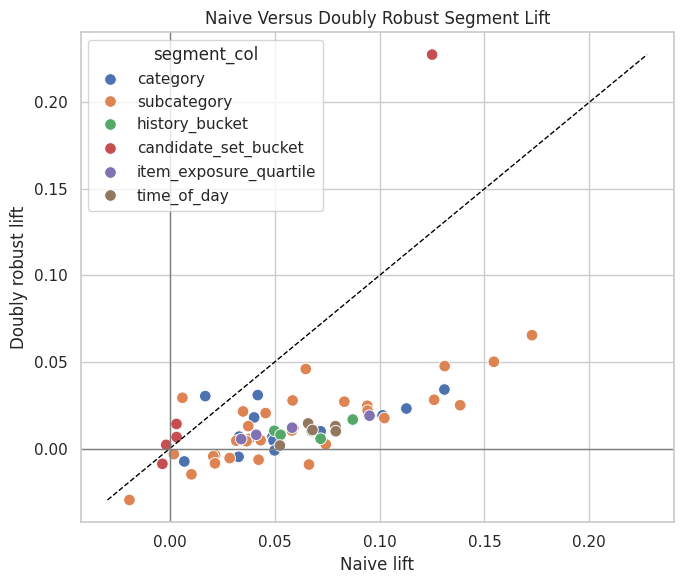

In [26]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=all_effects, x="naive_lift", y="dr_lift", hue="segment_col", s=70)
lims = [min(all_effects["naive_lift"].min(), all_effects["dr_lift"].min()), max(all_effects["naive_lift"].max(), all_effects["dr_lift"].max())]
plt.plot(lims, lims, color="black", linestyle="--", linewidth=1)
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.title("Naive Versus Doubly Robust Segment Lift")
plt.xlabel("Naive lift")
plt.ylabel("Doubly robust lift")
plt.tight_layout()

The naive lift quantifies the raw click-rate gap between treatment and control groups. It is the starting point for the project: later notebooks ask how much of this apparent lift remains after adjustment.


## Final Takeaways

The global top-3 effect is useful, but it is not the whole decision problem. Segment estimates show whether incremental engagement is concentrated in specific content groups, user-history groups, candidate-set sizes, baseline-exposure levels, or usage times.

These results should be used to prioritize follow-up experiments and guardrails. Large positive segment estimates suggest where visibility may create the most incremental engagement, while noisy or weak segments should not be promoted aggressively without stronger evidence. The remaining risks are the usual observational ones: unobserved confounding, limited feature coverage, overlap, and the need for online experimentation before changing the ranking policy.
